# Quickstart: classify a point cloud

This notebook will guide you on how to use the `torch-pointcloud` library to classify a point cloud. it will cover:

- the **model registry** and the `create_model` factory (the `timm`-style entry point),
- the **packed-batch** tensor format (the PyTorch Geometric convention used everywhere here).

## Setup

In [1]:
# On Colab, install the library first (uncomment):
# !pip install "torch-pointcloud"

import torch

import torch_pointcloud as tp

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch-pointcloud", tp.__version__, "| torch", torch.__version__, "| device:", device)

torch-pointcloud 0.1.0 | torch 2.10.0+cu128 | device: cuda


## Download a sample object

First, let's download a sample object.

In [2]:
import urllib.request
from pathlib import Path


def download_sample(filename):
    """Read one object committed with these docs, downloading it when run outside a docs checkout."""
    url = f"https://github.com/arthurdjn/pytorch-pointcloud/raw/main/docs/assets/data/{filename}"
    if not Path(filename).exists():
        urllib.request.urlretrieve(url, filename)

In [3]:
for name in ("sample.ply", "sample_chair.ply", "sample_lamp.ply"):
    download_sample(name)

Let's load the sample objects:

In [20]:
import numpy as np
from plyfile import PlyData


def load_sample(filename):
    vertex = PlyData.read(filename)["vertex"]
    pos = torch.from_numpy(np.stack([vertex["x"], vertex["y"], vertex["z"]], axis=1).astype(np.float32))
    return {"pos": pos}

In [21]:
data_list = [load_sample(filename) for filename in ("sample_car.ply", "sample_chair.ply", "sample_lamp.ply")]

Let's visualize the downloaded objects:

In [23]:
import matplotlib.pyplot as plt


def show_cloud(pos, color=None, *, ax=None, title=None, size=6, cmap="viridis"):
    """Scatter a point cloud. `pos` is (N, 3); `color` is per-point RGB, a label vector, or None."""
    if ax is None:
        ax = plt.figure(figsize=(4, 4)).add_subplot(projection="3d")

    p = pos.detach().cpu().numpy()
    c = color.detach().cpu().numpy() if torch.is_tensor(color) else color
    kw = {} if c is None else {"cmap": cmap}
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], c=c, s=size, depthshade=False, linewidths=0, **kw)
    ax.set_box_aspect((1, 1, 1))
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10)
    return ax

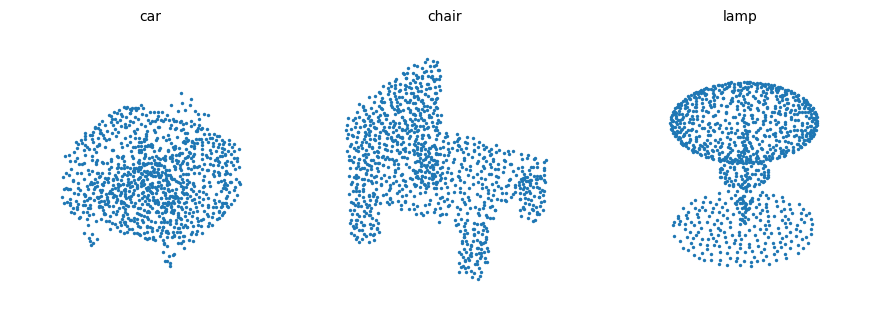

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2), subplot_kw={"projection": "3d"})
for ax, data, title in zip(axes, data_list, ["car", "chair", "lamp"]):
    pos = data["pos"][:, [0, 2, 1]]  # the .ply objects are y-up, plot them z-up
    show_cloud(pos, title=title, ax=ax)

plt.tight_layout()
plt.show()

## Find a model in the registry

Models are built by name through a single factory, `create_model`, mirroring `timm.create_model`. Names follow the pattern `<arch>-<variant>.<dataset>`, for example `pointnet2-ssg.modelnet40.xu-yan`.

List what is available for a task with `list_models` (it accepts a glob):

In [4]:
from torch_pointcloud.models import list_models

list_models("pointnet2*", task="classification")
# ['pointnet2-msg.modelnet40.xu-yan',
#  'pointnet2-ssg.modelnet40.xu-yan',
#  'pointnet2.modelnet40.openpoints',
#  'pointnet2.scanobjectnn.openpoints']

['pointnet2-msg.modelnet40.xu-yan',
 'pointnet2-ssg.modelnet40.xu-yan',
 'pointnet2.modelnet40.openpoints',
 'pointnet2.scanobjectnn.openpoints']

You can use the `pretrained=True` to filter only models with pretrained weights:

In [5]:
list_models("pointnet2*", task="classification", pretrained=True)
# ['pointnet2-msg.modelnet40.xu-yan',
#  'pointnet2-ssg.modelnet40.xu-yan',
#  'pointnet2.modelnet40.openpoints',
#  'pointnet2.scanobjectnn.openpoints']

['pointnet2-msg.modelnet40.xu-yan',
 'pointnet2-ssg.modelnet40.xu-yan',
 'pointnet2.modelnet40.openpoints',
 'pointnet2.scanobjectnn.openpoints']

## Build a model

`create_model(name, task=...)` returns a ready `nn.Module`.

- `pretrained=True` loads the registered weights (cached locally). We leave it off here so the cell runs anywhere with no download: you get the architecture with random weights.
- `return_info=True` also returns the registry entry, including the exact transform pipeline the checkpoint was trained with (used in the [segmentation notebook](02-segmentation-inference.md)).

The factory returns a typed `ClassificationModel`, so `.num_classes`, `.eval()`, and `.to(device)` work as usual.

In [6]:
model = tp.create_model(
    "pointnet2-ssg.modelnet40.xu-yan", 
    task="classification",
    pretrained=True,
).eval().to(device)

n_params = sum(p.numel() for p in model.parameters())
print(type(model).__name__, "| classes:", model.num_classes, "| parameters:", f"{n_params:,}")
# PointNet2Classification | classes: 40 | parameters: 1,475,688

PointNet2Classification | classes: 40 | parameters: 1,475,688


Use `return_info=True` to get associated information, like the transform pipeline:

In [7]:
model, info = tp.create_model(
    "pointnet2-ssg.modelnet40.xu-yan", 
    task="classification",
    pretrained=True,
    return_info=True,
)

info

{'name': 'pointnet2-ssg.modelnet40.xu-yan',
 'transform': Compose(
   FarthestPointSample(keys=('pos',), allow_missing_keys=False, pos_key='pos', num_samples=1024, ratio=None, random_start=False),
   Rescale(keys=('pos',), allow_missing_keys=False, eps=1e-06, method='centroid')
 ),
 'hparams': {'in_channels': 0,
  'num_classes': 40,
  'sa_channels': [[64, 64, 128], [128, 128, 256]],
  'aggr_channels': [256, 512, 1024],
  'aggr_use_pos': True,
  'head_channels': [512, 256],
  'ratios': [0.5, 0.25],
  'radii': [0.2, 0.4],
  'num_neighbors': [32, 64],
  'use_pos': True,
  'normalize_pos': False,
  'bias': True,
  'dropout': 0.4},
 'weights': {'url': 'hf://torch-pointcloud/pointnet2/pointnet2-ssg.modelnet40.xu-yan.safetensors',
  'dataset': 'modelnet40',
  'metrics': {'OA': 92.3},
  'classes': ('airplane',
   'bathtub',
   'bed',
   'bench',
   'bookshelf',
   'bottle',
   'bowl',
   'car',
   'chair',
   'cone',
   'cup',
   'curtain',
   'desk',
   'door',
   'dresser',
   'flower_pot',


Note that you can also instantiate your own model using the class itself, here using `torch_pointcloud.models.PointNet2Classification`, but you will loose the pretrained weights and transform pipeline. Use the below code when you want to customize your own model, for your own dataset.

In [8]:
from torch_pointcloud.models import PointNet2Classification

_ = PointNet2Classification(
    in_channels=0,
    num_classes=40,
    sa_channels=[[64, 64, 128], [128, 128, 256]],
    aggr_channels=[256, 512, 1024],
    aggr_use_pos=True,
    head_channels=[512, 256],
    ratios=[0.5, 0.25],
    radii=[0.2, 0.4],
    num_neighbors=[32, 64],
    use_pos=True,
    normalize_pos=False,
    bias=True,
    dropout=0.4,
)

## The packed-batch format

A batch of point clouds is stored *packed*: all points concatenated into one flat tensor, with a companion `batch` vector giving each point's cloud index. Nothing is padded to a common size.

| tensor  | shape    | meaning                                                  |
| ------- | -------- | -------------------------------------------------------- |
| `pos`   | $(N, 3)$ | XYZ of every point in the batch, concatenated            |
| `x`     | $(N, C)$ | optional per-point features (`None` uses coordinates only) |
| `batch` | $(N,)$   | cloud index in $[0, B)$ for each point                   |

For $B$ clouds with $N_i$ points each, $N = N_1 + \cdots + N_B$.
The `batch` tensor is a flat vector of length $N$ that maps each point to its cloud index, ranging from $0$ to $B-1$.

To make things easier, we provide a `collate` helper that builds the `batch` vector for you and concatenates / stacks tensors as needed.

![Animation contrasting three ways to hold a batch of clouds: a Python list, a padded tensor, and the packed layout used here.](../assets/animations/batch_modes.webp)

In [36]:
from torch_pointcloud.utils.data import collate

data_list = [load_sample(filename) for filename in ("sample_car.ply", "sample_chair.ply", "sample_lamp.ply")]

# Run the transform / preprocessing before collating
data_list = [info["transform"](data) for data in data_list]

data = collate(data_list)

print(data.keys())
print(data["pos"].shape)
print(data["batch"].shape)
# dict_keys(['pos', 'batch'])
# torch.Size([3072, 3])
# torch.Size([3072])

dict_keys(['pos', 'batch'])
torch.Size([3072, 3])
torch.Size([3072])


## Run the model

A classification model is called as `model(x, pos, batch)`: features first (here `None`), then coordinates, then the batch index. It returns one logit vector per cloud, shape $(B, \text{num\_classes})$.

In [37]:
model = model.eval().to(device)
with torch.no_grad():
    logits = model(None, data["pos"].to(device), data["batch"].to(device))

print("logits:", logits.shape)
# logits: torch.Size([3, 40])

logits: torch.Size([3, 40])


## Visualize the prediction

Turn logits into probabilities with a softmax, take the top-k, and map indices to ModelNet40 class names.

In [53]:
probs = logits.softmax(dim=-1)
preds = probs.argmax(dim=-1)
topk = probs.topk(3, dim=-1)
for i in range(probs.shape[0]):
    names = (info["weights"]["classes"][j] for j in topk.indices[i].tolist())
    scores = (f"{s:.2f}" for s in topk.values[i].tolist())
    print(f"cloud {i}: " + ", ".join(f"{n} ({s})" for n, s in zip(names, scores)))

# cloud 0: car (1.00), range_hood (0.00), tv_stand (0.00)
# cloud 1: chair (0.62), stool (0.22), bench (0.12)
# cloud 2: lamp (1.00), stool (0.00), person (0.00)

cloud 0: car (1.00), range_hood (0.00), tv_stand (0.00)
cloud 1: chair (0.62), stool (0.22), bench (0.12)
cloud 2: lamp (1.00), stool (0.00), person (0.00)


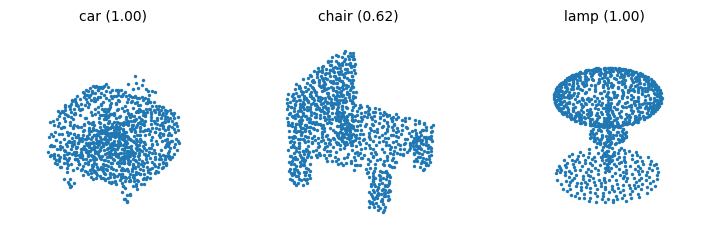

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2), subplot_kw={"projection": "3d"})
for i, ax in enumerate(axes):
    class_name = info["weights"]["classes"][preds[i]]
    pos = data["pos"][data["batch"] == i]
    show_cloud(pos[:, [0, 2, 1]], title=f"{class_name} ({probs[i, preds[i]]:.2f})", ax=ax)

![Three objects, each captioned with the class the pretrained classifier gives it: car at 1.00, chair at 0.62, lamp at 1.00.](../assets/tutorials/quickstart_prediction.png)